<a href="https://colab.research.google.com/github/NanditaPatil-dotcom/PhysSAE/blob/main/PhysSAE_Failure_Diagnostics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Setup

In [ ]:
import os
import time
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.decomposition import PCA


# Reproducibility
torch.manual_seed(0)
np.random.seed(0)
torch.set_num_threads(4)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", DEVICE)

# Publication plotting style
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 220,
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Output folders
os.makedirs("artifacts", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# PINN Hyperparameters
HIDDEN      = 40
N_LAYERS    = 4
PINN_ITERS  = 4000

# PhysSAE Hyperparameters
DICT         = 128
LAM_L1       = 5e-2
SAE_EPOCHS   = 500

# Evaluation Grid
NX = 256
NT = 100



Running on: cpu

Failure-mode experiments
convection           : {'success': 1, 'failure': 50}
burgers              : {'success': 0.01, 'failure': 0.001}
reaction_diffusion   : {'success': 1, 'failure': 100}


# 2. PINN architecture






In [ ]:
class PINN(nn.Module):

    def __init__(self, out_dim=1, layers=None):
        super().__init__()

        layers = layers or ([2] + [HIDDEN] * N_LAYERS + [out_dim])

        self.net = nn.ModuleList([
            nn.Linear(layers[i], layers[i + 1])
            for i in range(len(layers) - 1)
        ])

        self.act = nn.Tanh()

        for m in self.net:
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)

        # Cached penultimate-layer activations
        self._hidden = None

    def forward(self, x, t):

        h = torch.cat([x, t], dim=1)

        for layer in self.net[:-1]:
            h = self.act(layer(h))

        # Save hidden representation for PhysSAE
        self._hidden = h

        return self.net[-1](h)

    @property
    def hidden(self):
        """Return cached penultimate activations."""
        return self._hidden

# 3. Training PINN

In [ ]:
def train_pinn(loss_fn,n_iter=PINN_ITERS,lr=1e-3,log_every=400,tag="pinn",out_dim=1,):

    model = PINN(out_dim=out_dim).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    t0 = time.time()

    for it in range(n_iter):
        optimizer.zero_grad()
        loss, parts = loss_fn(model)
        loss.backward()
        optimizer.step()
        history.append(parts)

        if (it % log_every == 0) or (it == n_iter - 1):

            print(
                f"[{tag}] "
                f"Iter {it:4d}/{n_iter} | "
                f"BC={parts[0]:.2e} "
                f"IC={parts[1]:.2e} "
                f"PDE={parts[2]:.2e}"
            )

    elapsed = time.time() - t0
    print(f"[{tag}] Finished in {elapsed:.1f} s")
    history = np.asarray(history)

    # Save artifacts automatically
    torch.save(model.state_dict(),f"artifacts/{tag}_pinn.pt")
    np.save(f"artifacts/{tag}_history.npy",history)
    return model, history

# 4. Train on PDEs

## 1. Advection-Diffusion

In [20]:
def advection_diffusion_loss(model, beta, nu):

    n_b, n_i, n_f = 100, 100, 2500
    t_b = torch.rand(n_b, 1, device=DEVICE)

    x_left  = -torch.ones(n_b, 1, device=DEVICE)
    x_right =  torch.ones(n_b, 1, device=DEVICE)

    u_left  = model(x_left, t_b)
    u_right = model(x_right, t_b)

    # derivative periodicity

    x_left_g  = x_left.clone().requires_grad_(True)
    x_right_g = x_right.clone().requires_grad_(True)

    u_left_g  = model(x_left_g, t_b)
    u_right_g = model(x_right_g, t_b)

    u_left_x = torch.autograd.grad(u_left_g,x_left_g,torch.ones_like(u_left_g),create_graph=True)[0]
    u_right_x = torch.autograd.grad(u_right_g,x_right_g,torch.ones_like(u_right_g),create_graph=True)[0]

    l_bc = ((u_left-u_right).pow(2).mean()+(u_left_x-u_right_x).pow(2).mean())

    # Initial condition
    x_i = 2*torch.rand(n_i,1,device=DEVICE)-1
    t_i = torch.zeros(n_i,1,device=DEVICE)
    u_true = torch.sin(torch.pi*x_i)
    u_pred = model(x_i,t_i)
    l_ic = ((u_pred-u_true)**2).mean()

    # PDE residual
    x_f = 2*torch.rand(n_f,1,device=DEVICE)-1
    t_f = torch.rand(n_f,1,device=DEVICE)

    x_f.requires_grad_(True)
    t_f.requires_grad_(True)

    u = model(x_f,t_f)

    u_t = torch.autograd.grad(u,t_f,torch.ones_like(u),create_graph=True)[0]
    u_x = torch.autograd.grad(u,x_f,torch.ones_like(u),create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x,x_f,torch.ones_like(u_x),create_graph=True)[0]
    residual = u_t + beta*u_x - nu*u_xx

    l_f = (residual**2).mean()

    total = 100*l_bc + 100*l_ic + l_f

    return total, (l_bc.item(),l_ic.item(),l_f.item(),)


# Success / Failure Experiments
ADVECTION_DIFFUSION_CASES = {

    "success": {
        "beta":1,
        "nu":1e-1,
    },

    "failure": {
        "beta":50,
        "nu":1e-3,
    },
}

ad_models = {}
ad_hists  = {}

for case, params in ADVECTION_DIFFUSION_CASES.items():

    beta = params["beta"]
    nu   = params["nu"]
    model_file = f"artifacts/advection_diffusion_{case}.pt"
    hist_file  = f"artifacts/advection_diffusion_{case}_hist.npy"

    if os.path.exists(model_file):
        model = PINN(out_dim=1).to(DEVICE)
        model.load_state_dict(torch.load(model_file, map_location=DEVICE))
        hist = np.load(hist_file)
        print(
            f"Loaded {case} "
            f"(β={beta}, ν={nu})"
        )

    else:
        print(
            f"\nTraining {case} "
            f"(β={beta}, ν={nu})"
        )
        loss_fn = lambda m, b=beta, n=nu: \
            advection_diffusion_loss(m, b, n)

        model, hist = train_pinn(loss_fn,tag=f"advection_diffusion_{case}",)

    ad_models[case] = model
    ad_hists[case] = hist

print("\nFinished Advection-Diffusion experiments.")


Training success (β=1, ν=0.1)
[advection_diffusion_success] Iter    0/4000 | BC=1.81e-01 IC=6.97e-01 PDE=1.98e-01
[advection_diffusion_success] Iter  400/4000 | BC=2.83e-03 IC=6.63e-03 PDE=7.33e-01
[advection_diffusion_success] Iter  800/4000 | BC=1.92e-04 IC=1.29e-03 PDE=4.68e-01
[advection_diffusion_success] Iter 1200/4000 | BC=2.01e-04 IC=5.69e-04 PDE=4.39e-01
[advection_diffusion_success] Iter 1600/4000 | BC=6.10e-04 IC=7.55e-04 PDE=3.79e-01
[advection_diffusion_success] Iter 2000/4000 | BC=2.77e-04 IC=4.52e-04 PDE=3.20e-01
[advection_diffusion_success] Iter 2400/4000 | BC=6.31e-05 IC=1.50e-04 PDE=2.81e-01
[advection_diffusion_success] Iter 2800/4000 | BC=1.38e-03 IC=2.96e-04 PDE=2.61e-01
[advection_diffusion_success] Iter 3200/4000 | BC=8.79e-05 IC=3.95e-05 PDE=2.21e-01
[advection_diffusion_success] Iter 3600/4000 | BC=1.51e-04 IC=4.40e-05 PDE=1.85e-01
[advection_diffusion_success] Iter 3999/4000 | BC=1.94e-03 IC=4.53e-04 PDE=1.51e-01
[advection_diffusion_success] Finished in 411

## 2. Convection equation

In [24]:
def convection_loss(model, beta):

    n_b, n_i, n_f = 100, 100, 2500
    t_b = torch.rand(n_b, 1, device=DEVICE)
    x_left  = -torch.ones(n_b, 1, device=DEVICE)
    x_right =  torch.ones(n_b, 1, device=DEVICE)
    u_left  = model(x_left, t_b)
    u_right = model(x_right, t_b)

    # derivative periodicity

    x_left_g = x_left.clone().requires_grad_(True)
    x_right_g = x_right.clone().requires_grad_(True)
    u_left_g = model(x_left_g, t_b)
    u_right_g = model(x_right_g, t_b)
    u_left_x = torch.autograd.grad(u_left_g,x_left_g,torch.ones_like(u_left_g),create_graph=True,)[0]
    u_right_x = torch.autograd.grad(u_right_g,x_right_g,torch.ones_like(u_right_g),create_graph=True)[0]

    l_bc = (
        (u_left - u_right).pow(2).mean()
        +
        (u_left_x - u_right_x).pow(2).mean()
    )

    x_i = 2 * torch.rand(n_i, 1, device=DEVICE) - 1
    t_i = torch.zeros(n_i, 1, device=DEVICE)
    u_true = torch.sin(torch.pi * x_i)
    u_pred = model(x_i, t_i)
    l_ic = ((u_pred - u_true) ** 2).mean()
    x_f = 2 * torch.rand(n_f, 1, device=DEVICE) - 1
    t_f = torch.rand(n_f, 1, device=DEVICE)
    x_f.requires_grad_(True)
    t_f.requires_grad_(True)
    u = model(x_f, t_f)
    u_t = torch.autograd.grad(u,t_f,torch.ones_like(u),create_graph=True,)[0]
    u_x = torch.autograd.grad(u,x_f,torch.ones_like(u),create_graph=True,)[0]

    residual = u_t + beta * u_x
    l_f = (residual ** 2).mean()
    total = 100 * l_bc + 100 * l_ic + l_f
    return total, (l_bc.item(),l_ic.item(),l_f.item(),)


CONVECTION_CASES = {
    "success": 1,
    "failure": 50,
}

conv_models = {}
conv_hists = {}

for case, beta in CONVECTION_CASES.items():
    model_file = f"artifacts/conv_{case}.pt"
    hist_file = f"artifacts/conv_{case}_hist.npy"

    if os.path.exists(model_file):
        model = PINN(out_dim=1).to(DEVICE)
        model.load_state_dict(torch.load(model_file, map_location=DEVICE))
        hist = np.load(hist_file)
        print(f"Loaded cached {case} model (β={beta})")

    else:

        print(f"\nTraining {case} model (β={beta})")
        loss_fn = lambda m, b=beta: convection_loss(m, b)
        model, hist = train_pinn(loss_fn,tag=f"conv_{case}",)

    conv_models[case] = model
    conv_hists[case] = hist

print("\nFinished convection experiments.")


Training success model (β=1)
[conv_success] Iter    0/4000 | BC=1.35e-01 IC=3.76e-01 PDE=4.76e-03
[conv_success] Iter  400/4000 | BC=1.19e-03 IC=2.60e-03 PDE=9.38e-01
[conv_success] Iter  800/4000 | BC=1.98e-04 IC=8.67e-04 PDE=6.81e-01
[conv_success] Iter 1200/4000 | BC=3.57e-04 IC=5.09e-04 PDE=5.36e-01
[conv_success] Iter 1600/4000 | BC=1.32e-03 IC=2.30e-04 PDE=4.54e-01
[conv_success] Iter 2000/4000 | BC=4.47e-04 IC=9.08e-05 PDE=3.87e-01
[conv_success] Iter 2400/4000 | BC=3.70e-04 IC=1.05e-04 PDE=3.49e-01
[conv_success] Iter 2800/4000 | BC=3.30e-04 IC=7.48e-05 PDE=3.02e-01
[conv_success] Iter 3200/4000 | BC=4.20e-04 IC=1.93e-04 PDE=2.72e-01
[conv_success] Iter 3600/4000 | BC=4.63e-04 IC=2.37e-04 PDE=2.14e-01
[conv_success] Iter 3999/4000 | BC=1.13e-03 IC=2.88e-04 PDE=1.64e-01
[conv_success] Finished in 306.0 s

Training failure model (β=50)
[conv_failure] Iter    0/4000 | BC=4.21e-02 IC=5.47e-01 PDE=2.66e+01
[conv_failure] Iter  400/4000 | BC=3.24e-02 IC=1.99e-01 PDE=1.75e+00
[conv_f

## 3. Reaction-diffusion

In [26]:
D = 1e-3        # diffusion coefficient

def reaction_loss(model, k):

    n_b, n_i, n_f = 100, 100, 2500
    t_b = torch.rand(n_b, 1, device=DEVICE)

    x_left  = -torch.ones(n_b, 1, device=DEVICE)
    x_right =  torch.ones(n_b, 1, device=DEVICE)

    u_left  = model(x_left, t_b)
    u_right = model(x_right, t_b)

    l_bc = (u_left**2).mean() + (u_right**2).mean()
    x_i = 2 * torch.rand(n_i, 1, device=DEVICE) - 1
    t_i = torch.zeros(n_i, 1, device=DEVICE)

    u_true = torch.exp(-10 * x_i**2)

    u_pred = model(x_i, t_i)

    l_ic = ((u_pred - u_true)**2).mean()

    x_f = 2 * torch.rand(n_f, 1, device=DEVICE) - 1
    t_f = torch.rand(n_f, 1, device=DEVICE)

    x_f.requires_grad_(True)
    t_f.requires_grad_(True)

    u = model(x_f, t_f)

    u_t = torch.autograd.grad(u,t_f,torch.ones_like(u),create_graph=True)[0]
    u_x = torch.autograd.grad(u,x_f,torch.ones_like(u),create_graph=True,)[0]
    u_xx = torch.autograd.grad(u_x,x_f,torch.ones_like(u_x),create_graph=True,)[0]

    reaction = k * u * (1 - u)
    residual = u_t - D * u_xx - reaction
    l_f = (residual**2).mean()
    total = 100*l_bc + 100*l_ic + l_f

    return total, (l_bc.item(),l_ic.item(),l_f.item(),)


REACTION_CASES = {
    "success": 1,
    "failure": 100,
}

reac_diff_models = {}
reac_diff_hists  = {}

for case, k in REACTION_CASES.items():

    model_file = f"artifacts/reaction_{case}.pt"
    hist_file  = f"artifacts/reaction_{case}_hist.npy"

    if os.path.exists(model_file):

        model = PINN(out_dim=1).to(DEVICE)

        model.load_state_dict(
            torch.load(model_file, map_location=DEVICE)
        )

        hist = np.load(hist_file)

        print(f"Loaded cached Reaction-Diffusion {case} (k={k})")

    else:

        print(f"\nTraining Reaction-Diffusion {case} (k={k})")

        loss_fn = lambda m, kk=k: reaction_loss(m, kk)

        model, hist = train_pinn(
            loss_fn,
            tag=f"reaction_{case}",
        )

    reac_diff_models[case] = model
    reac_diff_hists[case] = hist

print("\nFinished Reaction-Diffusion experiments.")


Training Reaction-Diffusion success (k=1)
[reaction_success] Iter    0/4000 | BC=9.38e-02 IC=2.29e-01 PDE=6.20e-02
[reaction_success] Iter  400/4000 | BC=4.83e-05 IC=3.74e-04 PDE=5.77e-03
[reaction_success] Iter  800/4000 | BC=7.11e-06 IC=4.35e-05 PDE=3.44e-03
[reaction_success] Iter 1200/4000 | BC=1.10e-05 IC=1.83e-05 PDE=2.00e-03
[reaction_success] Iter 1600/4000 | BC=5.15e-06 IC=1.12e-05 PDE=1.32e-03
[reaction_success] Iter 2000/4000 | BC=8.59e-05 IC=2.72e-05 PDE=1.12e-03
[reaction_success] Iter 2400/4000 | BC=8.27e-06 IC=9.62e-06 PDE=9.37e-04
[reaction_success] Iter 2800/4000 | BC=4.73e-06 IC=6.55e-06 PDE=8.09e-04
[reaction_success] Iter 3200/4000 | BC=6.86e-05 IC=2.40e-05 PDE=7.72e-04
[reaction_success] Iter 3600/4000 | BC=7.21e-05 IC=3.07e-05 PDE=6.55e-04
[reaction_success] Iter 3999/4000 | BC=6.70e-07 IC=6.13e-06 PDE=5.91e-04
[reaction_success] Finished in 451.4 s

Training Reaction-Diffusion failure (k=100)
[reaction_failure] Iter    0/4000 | BC=1.15e-01 IC=1.81e-01 PDE=5.26e+

# 5. Evaluate All PINNs on a dense grid



In [28]:
nx, nt = 256, 100

xs = torch.linspace(-1, 1, nx, device=DEVICE).reshape(-1,1)
ts = torch.linspace(0, 1, nt, device=DEVICE).reshape(-1,1)

X, T = torch.meshgrid(xs.squeeze(), ts.squeeze(), indexing="ij")

XF = X.reshape(-1,1)
TF = T.reshape(-1,1)

np.save("artifacts/grid_x.npy", xs.cpu().numpy().squeeze())
np.save("artifacts/grid_t.npy", ts.cpu().numpy().squeeze())


def eval_pinn_and_hidden(model):

    model.eval()

    with torch.no_grad():

        U = model(XF, TF).reshape(nx, nt).cpu().numpy()

        H = (
            model._hidden
            .detach()
            .reshape(nx, nt, HIDDEN)
            .cpu()
            .numpy()
        )

    return U, H


U_adv_s, H_adv_s = eval_pinn_and_hidden(ad_models["success"])

np.save("artifacts/advection_diffusion_success_U.npy", U_adv_s)
np.save("artifacts/advection_diffusion_success_H.npy", H_adv_s)

U_adv_f, H_adv_f = eval_pinn_and_hidden(ad_models["failure"])

np.save("artifacts/advection_diffusion_failure_U.npy", U_adv_f)
np.save("artifacts/advection_diffusion_failure_H.npy", H_adv_f)


U_conv_s, H_conv_s = eval_pinn_and_hidden(conv_models["success"])

np.save("artifacts/convection_success_U.npy", U_conv_s)
np.save("artifacts/convection_success_H.npy", H_conv_s)

U_conv_f, H_conv_f = eval_pinn_and_hidden(conv_models["failure"])

np.save("artifacts/convection_failure_U.npy", U_conv_f)
np.save("artifacts/convection_failure_H.npy", H_conv_f)

U_reac_s, H_reac_s = eval_pinn_and_hidden(reac_diff_models["success"])

np.save("artifacts/reaction_diffusion_success_U.npy", U_reac_s)
np.save("artifacts/reaction_diffusion_success_H.npy", H_reac_s)

U_reac_f, H_reac_f = eval_pinn_and_hidden(reac_diff_models["failure"])

np.save("artifacts/reaction_diffusion_failure_U.npy", U_reac_f)
np.save("artifacts/reaction_diffusion_failure_H.npy", H_reac_f)


print(f"Advection-Diffusion (Success)   U range [{U_adv_s.min():.3f}, {U_adv_s.max():.3f}], H shape {H_adv_s.shape}")
print(f"Advection-Diffusion (Failure)   U range [{U_adv_f.min():.3f}, {U_adv_f.max():.3f}], H shape {H_adv_f.shape}")
print(f"Convection (Success)            U range [{U_conv_s.min():.3f}, {U_conv_s.max():.3f}], H shape {H_conv_s.shape}")
print(f"Convection (Failure)            U range [{U_conv_f.min():.3f}, {U_conv_f.max():.3f}], H shape {H_conv_f.shape}")
print(f"Reaction-Diffusion (Success)    U range [{U_reac_s.min():.3f}, {U_reac_s.max():.3f}], H shape {H_reac_s.shape}")
print(f"Reaction-Diffusion (Failure)    U range [{U_reac_f.min():.3f}, {U_reac_f.max():.3f}], H shape {H_reac_f.shape}")

Advection-Diffusion (Success)   U range [-1.010, 1.025], H shape (256, 100, 40)
Advection-Diffusion (Failure)   U range [-0.871, 0.919], H shape (256, 100, 40)
Convection (Success)            U range [-1.001, 1.010], H shape (256, 100, 40)
Convection (Failure)            U range [-0.934, 0.957], H shape (256, 100, 40)
Reaction-Diffusion (Success)    U range [-0.004, 1.012], H shape (256, 100, 40)
Reaction-Diffusion (Failure)    U range [-0.020, 0.194], H shape (256, 100, 40)


### Figure 1 — PINN solutions and training history

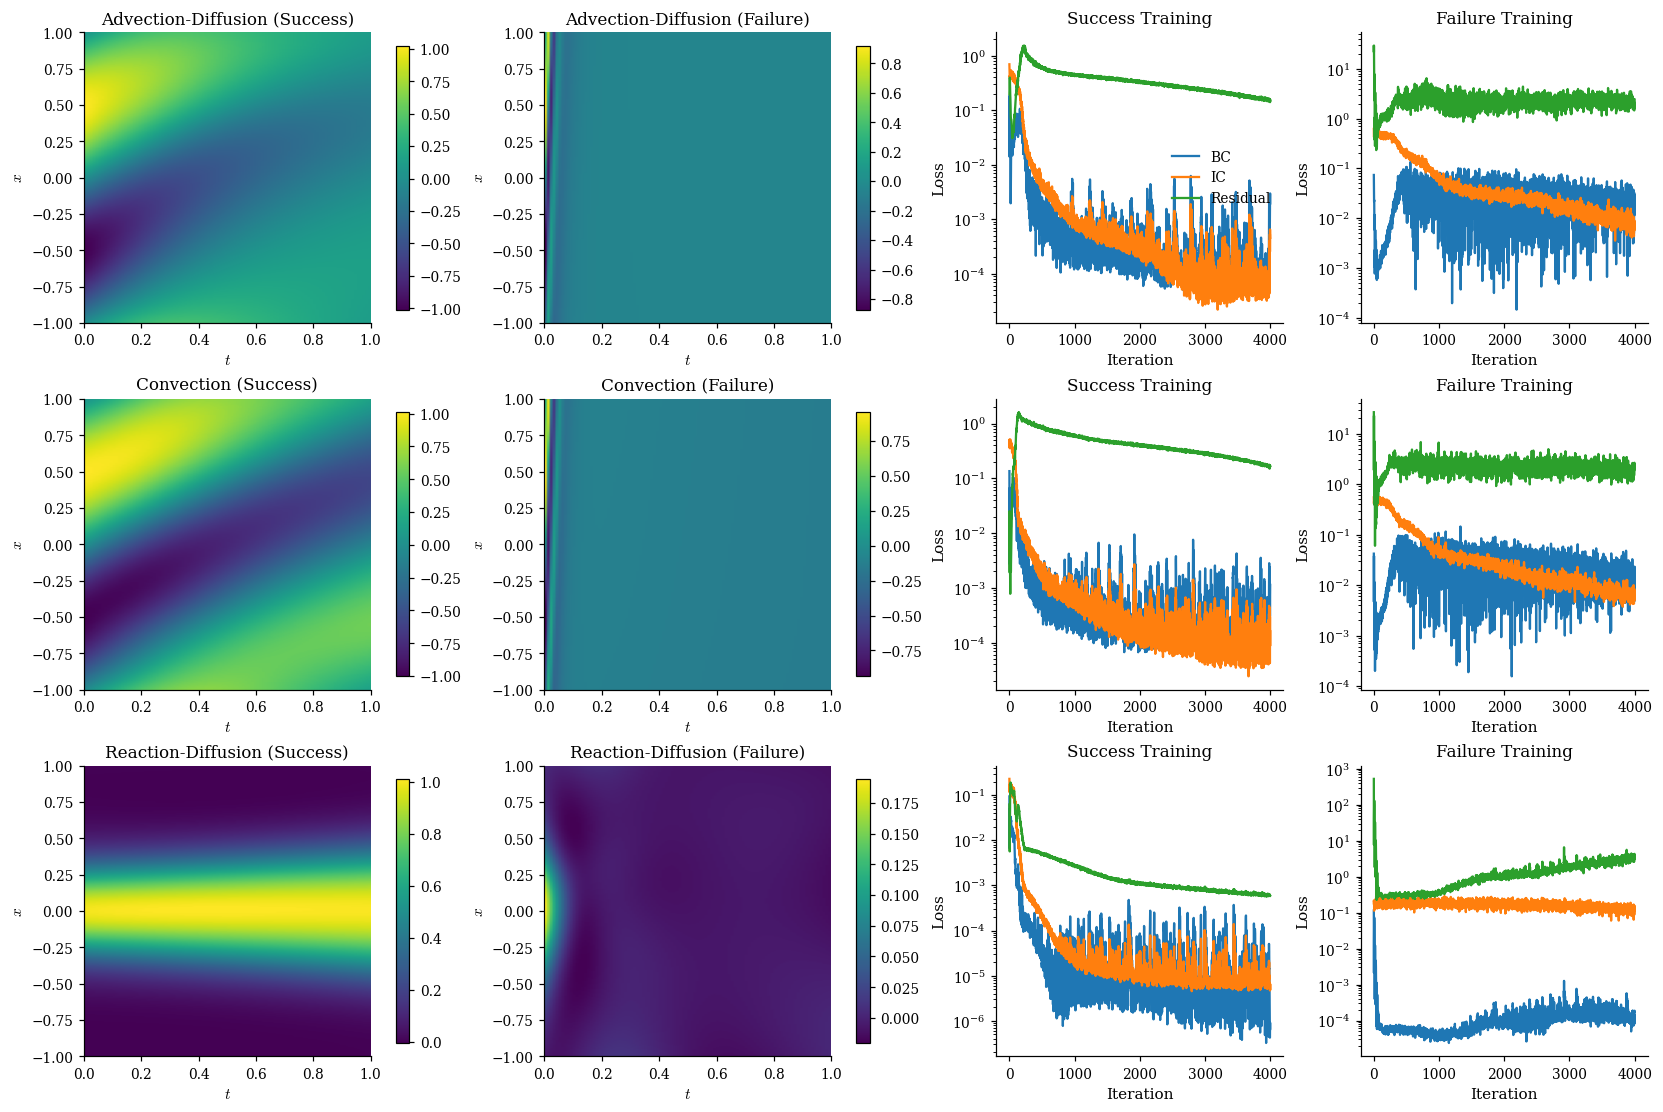

In [29]:
xs_np = xs.cpu().numpy().squeeze()
ts_np = ts.cpu().numpy().squeeze()
extent = [ts_np.min(),ts_np.max(),xs_np.min(),xs_np.max()]
fig, axes = plt.subplots(3,4,figsize=(15,10),constrained_layout=True)
rows = [

    (
        "Advection-Diffusion",
        ad_models["success"],
        ad_models["failure"],
        ad_hists["success"],
        ad_hists["failure"],
    ),

    (
        "Convection",
        conv_models["success"],
        conv_models["failure"],
        conv_hists["success"],
        conv_hists["failure"],
    ),

    (
        "Reaction-Diffusion",
        reac_diff_models["success"],
        reac_diff_models["failure"],
        reac_diff_hists["success"],
        reac_diff_hists["failure"],
    ),

]

for r,(name,model_s,model_f,hist_s,hist_f) in enumerate(rows):

    U_s,_ = eval_pinn_and_hidden(model_s)
    U_f,_ = eval_pinn_and_hidden(model_f)
    ax = axes[r,0]

    im = ax.imshow(U_s,extent=extent,origin="lower",aspect="auto",cmap="viridis",)
    ax.set_title(f"{name} (Success)")
    ax.set_xlabel("$t$")
    ax.set_ylabel("$x$")

    plt.colorbar(im,ax=ax,fraction=0.046)

    # Failure solution
    ax = axes[r,1]
    im = ax.imshow(U_f,extent=extent,origin="lower",aspect="auto",cmap="viridis",)
    ax.set_title(f"{name} (Failure)")
    ax.set_xlabel("$t$")
    ax.set_ylabel("$x$")

    plt.colorbar(im,ax=ax,fraction=0.046)

    # Success training
    ax = axes[r,2]

    for j,label in enumerate(["BC","IC","Residual"]):
        ax.semilogy(hist_s[:,j],label=label,)

    ax.set_title("Success Training")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")

    if r==0:
        ax.legend(frameon=False)

    # Failure training
    ax = axes[r,3]

    for j,label in enumerate(["BC","IC","Residual"]):
        ax.semilogy(hist_f[:,j],label=label,)

    ax.set_title("Failure Training")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")

plt.savefig("figures/fig1_failure_mode_pinns.png",bbox_inches="tight",)
plt.show()

In [30]:
print("="*95)
print(
    f"{'Experiment':25s}"
    f"{'BC':>12s}"
    f"{'IC':>12s}"
    f"{'Residual':>12s}"
    f"{'Total':>14s}"
)
print("="*95)


def show(name,hist):

    bc,ic,res = hist[-1]
    total = 100*bc + 100*ic + res
    print(
        f"{name:25s}"
        f"{bc:12.4e}"
        f"{ic:12.4e}"
        f"{res:12.4e}"
        f"{total:14.4e}"
    )


show("Advection-diffusion (Success)",ad_hists["success"])
show("Advection-diffusion (Failure)",ad_hists["failure"])

show("Convection (Success)",conv_hists["success"])
show("Convection (Failure)",conv_hists["failure"])

show("Reaction-diffusion (Success)",reac_diff_hists["success"])
show("Reaction-diffusion (Failure)",reac_diff_hists["failure"])

Experiment                         BC          IC    Residual         Total
Advection-diffusion (Success)  1.9422e-03  4.5344e-04  1.5108e-01    3.9064e-01
Advection-diffusion (Failure)  1.6777e-02  7.6320e-03  2.4058e+00    4.8467e+00
Convection (Success)       1.1342e-03  2.8844e-04  1.6360e-01    3.0587e-01
Convection (Failure)       4.9752e-03  5.2953e-03  2.0906e+00    3.1176e+00
Reaction-diffusion (Success)  6.6998e-07  6.1305e-06  5.9122e-04    1.2713e-03
Reaction-diffusion (Failure)  1.7341e-04  1.5266e-01  3.2628e+00    1.8546e+01


# 6. The sparse autoencoder



In [31]:
class SparseAutoencoder(nn.Module):
    def __init__(self, d_in=HIDDEN, d_dict=DICT):
        super().__init__()
        self.enc = nn.Linear(d_in, d_dict, bias=True)
        self.dec = nn.Linear(d_dict, d_in, bias=True)
        with torch.no_grad():
            self.dec.weight.copy_(self.dec.weight / (self.dec.weight.norm(dim=0, keepdim=True) + 1e-8))
        self.b_pre = nn.Parameter(torch.zeros(d_in))
    def encode(self, h): return torch.relu(self.enc(h - self.b_pre))
    def decode(self, z): return self.dec(z) + self.b_pre
    def forward(self, h):
        z = self.encode(h); return self.decode(z), z

def train_sae(H, n_epochs=SAE_EPOCHS, batch=4096, lr=1e-3, lam=LAM_L1, verbose=True):
    H_t = torch.from_numpy(H).float()
    N, d_in = H_t.shape
    sae = SparseAutoencoder(d_in=d_in, d_dict=DICT)
    opt = torch.optim.Adam(sae.parameters(), lr=lr)
    losses = []
    for ep in range(n_epochs):
        perm = torch.randperm(N)
        sums = [0.,0.,0.,0.]; nb = 0
        for s in range(0, N, batch):
            idx = perm[s:s+batch]; h = H_t[idx]
            h_hat, z = sae(h)
            recon = ((h_hat - h)**2).sum(dim=1).mean()
            l1 = z.abs().sum(dim=1).mean()
            loss = recon + lam*l1
            opt.zero_grad(); loss.backward(); opt.step()
            with torch.no_grad():
                w = sae.dec.weight
                sae.dec.weight.copy_(w / (w.norm(dim=0, keepdim=True) + 1e-8))
            l0 = (z > 1e-6).float().sum(dim=1).mean().item()
            for j,v in enumerate([loss.item(), recon.item(), l1.item(), l0]): sums[j]+=v
            nb += 1
        sums = [s/nb for s in sums]; losses.append(sums)
        if verbose and (ep % 100 == 0 or ep == n_epochs-1):
            print(f"  ep {ep:4d} | recon {sums[1]:.3e} | L1 {sums[2]:.2f} | L0 {sums[3]:.2f}")
    return sae, np.array(losses)


### Activation normalization

We z-score the PINN activations across the grid before feeding them to the SAE — a small but important detail. Without it the L1 penalty interacts asymmetrically with neurons of different magnitudes and decoder unit-norm becomes meaningless.

In [32]:
def normalize(H_flat):
    mu = H_flat.mean(0, keepdims=True)
    sd = H_flat.std(0, keepdims=True) + 1e-6
    return (H_flat - mu) / sd, mu, sd

# Flatten hidden activation

H_adv_s_flat  = H_adv_s.reshape(-1, HIDDEN)
H_adv_f_flat  = H_adv_f.reshape(-1, HIDDEN)

H_conv_s_flat = H_conv_s.reshape(-1, HIDDEN)
H_conv_f_flat = H_conv_f.reshape(-1, HIDDEN)

H_reac_s_flat = H_reac_s.reshape(-1, HIDDEN)
H_reac_f_flat = H_reac_f.reshape(-1, HIDDEN)


# Normalize

H_adv_s_n,  mu_adv_s,  sd_adv_s  = normalize(H_adv_s_flat)
H_adv_f_n,  mu_adv_f,  sd_adv_f  = normalize(H_adv_f_flat)

H_conv_s_n, mu_conv_s, sd_conv_s = normalize(H_conv_s_flat)
H_conv_f_n, mu_conv_f, sd_conv_f = normalize(H_conv_f_flat)

H_reac_s_n, mu_reac_s, sd_reac_s = normalize(H_reac_s_flat)
H_reac_f_n, mu_reac_f, sd_reac_f = normalize(H_reac_f_flat)

# Advection-Diffusion
np.save("artifacts/advection_diffusion_success_H_norm_mean.npy", mu_adv_s)
np.save("artifacts/advection_diffusion_success_H_norm_std.npy",  sd_adv_s)
np.save("artifacts/advection_diffusion_failure_H_norm_mean.npy", mu_adv_f)
np.save("artifacts/advection_diffusion_failure_H_norm_std.npy",  sd_adv_f)

# Convection
np.save("artifacts/convection_success_H_norm_mean.npy", mu_conv_s)
np.save("artifacts/convection_success_H_norm_std.npy",  sd_conv_s)
np.save("artifacts/convection_failure_H_norm_mean.npy", mu_conv_f)
np.save("artifacts/convection_failure_H_norm_std.npy",  sd_conv_f)

# Reaction-Diffusion
np.save("artifacts/reaction_diffusion_success_H_norm_mean.npy", mu_reac_s)
np.save("artifacts/reaction_diffusion_success_H_norm_std.npy",  sd_reac_s)
np.save("artifacts/reaction_diffusion_failure_H_norm_mean.npy", mu_reac_f)
np.save("artifacts/reaction_diffusion_failure_H_norm_std.npy",  sd_reac_f)


# Summary

print(f"Advection-Diffusion (Success)   : {H_adv_s_n.shape} | mean(|h|) = {np.abs(H_adv_s_n).mean():.3f}")
print(f"Advection-Diffusion (Failure)   : {H_adv_f_n.shape} | mean(|h|) = {np.abs(H_adv_f_n).mean():.3f}")

print(f"Convection (Success)            : {H_conv_s_n.shape} | mean(|h|) = {np.abs(H_conv_s_n).mean():.3f}")
print(f"Convection (Failure)            : {H_conv_f_n.shape} | mean(|h|) = {np.abs(H_conv_f_n).mean():.3f}")

print(f"Reaction-Diffusion (Success)    : {H_reac_s_n.shape} | mean(|h|) = {np.abs(H_reac_s_n).mean():.3f}")
print(f"Reaction-Diffusion (Failure)    : {H_reac_f_n.shape} | mean(|h|) = {np.abs(H_reac_f_n).mean():.3f}")

Advection-Diffusion (Success)   : (25600, 40) | mean(|h|) = 0.792
Advection-Diffusion (Failure)   : (25600, 40) | mean(|h|) = 0.335
Convection (Success)            : (25600, 40) | mean(|h|) = 0.829
Convection (Failure)            : (25600, 40) | mean(|h|) = 0.350
Reaction-Diffusion (Success)    : (25600, 40) | mean(|h|) = 0.881
Reaction-Diffusion (Failure)    : (25600, 40) | mean(|h|) = 0.833


## Train the all SAEs (~1 min each)

In [33]:
### Train all PhysSAEs (~1 min each)

def get_sae(tag, H_norm):

    pt = f"artifacts/{tag}_sae.pt"

    if os.path.exists(pt):
        sae = SparseAutoencoder().to(DEVICE)
        sae.load_state_dict(torch.load(pt, map_location=DEVICE))

        hist = np.load(f"artifacts/{tag}_sae_hist.npy")

        print(f"Loaded cached SAE for {tag}.")

        return sae, hist

    print(f"Training SAE for {tag}...")
    sae, hist = train_sae(H_norm)
    torch.save(sae.state_dict(), pt)
    np.save(f"artifacts/{tag}_sae_hist.npy", hist)

    return sae, hist


# Train SAEs
sae_adv_s,  sae_hist_adv_s  = get_sae("advection_diffusion_success",H_adv_s_n,)
sae_adv_f,  sae_hist_adv_f  = get_sae("advection_diffusion_failure",H_adv_f_n,)
sae_conv_s, sae_hist_conv_s = get_sae("convection_success",H_conv_s_n,)
sae_conv_f, sae_hist_conv_f = get_sae("convection_failure",H_conv_f_n,)
sae_reac_s, sae_hist_reac_s = get_sae("reaction_diffusion_success",H_reac_s_n,)
sae_reac_f, sae_hist_reac_f = get_sae("reaction_diffusion_failure",H_reac_f_n,)


# Encode activations
with torch.no_grad():

    Z_adv_s = (sae_adv_s.encode(torch.from_numpy(H_adv_s_n).float().to(DEVICE)).cpu().numpy().reshape(nx, nt, DICT))
    Z_adv_f = (sae_adv_f.encode(torch.from_numpy(H_adv_f_n).float().to(DEVICE)).cpu().numpy().reshape(nx, nt, DICT))
    Z_conv_s = (sae_conv_s.encode(torch.from_numpy(H_conv_s_n).float().to(DEVICE)).cpu().numpy().reshape(nx, nt, DICT))
    Z_conv_f = (sae_conv_f.encode(torch.from_numpy(H_conv_f_n).float().to(DEVICE)).cpu().numpy().reshape(nx, nt, DICT))
    Z_reac_s = (sae_reac_s.encode(torch.from_numpy(H_reac_s_n).float().to(DEVICE)).cpu().numpy().reshape(nx, nt, DICT))
    Z_reac_f = (sae_reac_f.encode(torch.from_numpy(H_reac_f_n).float().to(DEVICE)).cpu().numpy().reshape(nx, nt, DICT))

# Save sparse codes
np.save("artifacts/advection_diffusion_success_Z.npy", Z_adv_s)
np.save("artifacts/advection_diffusion_failure_Z.npy", Z_adv_f)
np.save("artifacts/convection_success_Z.npy", Z_conv_s)
np.save("artifacts/convection_failure_Z.npy", Z_conv_f)
np.save("artifacts/reaction_diffusion_success_Z.npy", Z_reac_s)
np.save("artifacts/reaction_diffusion_failure_Z.npy", Z_reac_f)


# Summary
print(
    f"Advection-Diffusion (Success) : "
    f"L0 = {sae_hist_adv_s[-1,3]:5.1f}/{DICT} | "
    f"Recon = {sae_hist_adv_s[-1,1]:.2e}"
)

print(
    f"Advection-Diffusion (Failure) : "
    f"L0 = {sae_hist_adv_f[-1,3]:5.1f}/{DICT} | "
    f"Recon = {sae_hist_adv_f[-1,1]:.2e}"
)

print(
    f"Convection (Success)          : "
    f"L0 = {sae_hist_conv_s[-1,3]:5.1f}/{DICT} | "
    f"Recon = {sae_hist_conv_s[-1,1]:.2e}"
)

print(
    f"Convection (Failure)          : "
    f"L0 = {sae_hist_conv_f[-1,3]:5.1f}/{DICT} | "
    f"Recon = {sae_hist_conv_f[-1,1]:.2e}"
)

print(
    f"Reaction-Diffusion (Success)  : "
    f"L0 = {sae_hist_reac_s[-1,3]:5.1f}/{DICT} | "
    f"Recon = {sae_hist_reac_s[-1,1]:.2e}"
)

print(
    f"Reaction-Diffusion (Failure)  : "
    f"L0 = {sae_hist_reac_f[-1,3]:5.1f}/{DICT} | "
    f"Recon = {sae_hist_reac_f[-1,1]:.2e}"
)

Training SAE for advection_diffusion_success...
  ep    0 | recon 5.421e+01 | L1 27.48 | L0 63.82
  ep  100 | recon 6.498e-02 | L1 14.53 | L0 45.53
  ep  200 | recon 3.302e-02 | L1 9.81 | L0 30.48
  ep  300 | recon 2.301e-02 | L1 8.37 | L0 23.82
  ep  400 | recon 1.843e-02 | L1 7.70 | L0 20.34
  ep  499 | recon 1.590e-02 | L1 7.32 | L0 18.32
Training SAE for advection_diffusion_failure...
  ep    0 | recon 4.146e+01 | L1 12.90 | L0 59.20
  ep  100 | recon 5.362e-02 | L1 6.69 | L0 23.33
  ep  200 | recon 2.378e-02 | L1 4.36 | L0 12.93
  ep  300 | recon 1.723e-02 | L1 3.52 | L0 9.08
  ep  400 | recon 1.262e-02 | L1 3.09 | L0 7.70
  ep  499 | recon 9.790e-03 | L1 2.88 | L0 6.91
Training SAE for convection_success...
  ep    0 | recon 5.011e+01 | L1 29.29 | L0 64.65
  ep  100 | recon 5.959e-02 | L1 14.73 | L0 46.39
  ep  200 | recon 3.230e-02 | L1 10.06 | L0 31.16
  ep  300 | recon 2.310e-02 | L1 8.65 | L0 24.31
  ep  400 | recon 1.814e-02 | L1 8.05 | L0 20.68
  ep  499 | recon 1.535e-02 |

# 7. Defining the ground-truth concept fields



In [43]:
def concepts_convection(U, xs, ts, beta):

    dx = xs[1] - xs[0]
    dt = ts[1] - ts[0]

    u_x = np.gradient(U, dx, axis=0)
    u_t = np.gradient(U, dt, axis=1)

    nx, nt = U.shape

    X = np.tile(xs.reshape(-1,1), (1, nt))
    T = np.tile(ts.reshape(1,-1), (nx, 1))

    concepts = {

        "|u|" : np.abs(U),
        "|u_x| (transport front)" : np.abs(u_x),
        "|u_t|" : np.abs(u_t),
        "u (signed)" : U,
        "x position" : X,
        "t (time)" : T,
        "characteristic" : X - beta*T,
    }


    return concepts


def concepts_advection_diffusion(U, xs, ts, beta, nu):

    dx = xs[1] - xs[0]
    dt = ts[1] - ts[0]

    u_x  = np.gradient(U, dx, axis=0)
    u_t  = np.gradient(U, dt, axis=1)
    u_xx = np.gradient(u_x, dx, axis=0)

    nx, nt = U.shape

    X = np.tile(xs.reshape(-1,1), (1, nt))
    T = np.tile(ts.reshape(1,-1), (nx, 1))

    return {

        "|u|" : np.abs(U),
        "|u_x| (transport)" : np.abs(u_x),
        "|u_xx| (diffusion)" : np.abs(u_xx),
        "|u_t|" : np.abs(u_t),
        "u (signed)" : U,
        "characteristic" : X - beta*T,
        "diffusion strength" : np.abs(nu*u_xx),
        "x position" : X,
        "t (time)" : T,
    }


def concepts_reaction_diffusion(U, xs, ts, k, D):

    dx = xs[1] - xs[0]
    dt = ts[1] - ts[0]

    u_x  = np.gradient(U, dx, axis=0)
    u_t  = np.gradient(U, dt, axis=1)
    u_xx = np.gradient(u_x, dx, axis=0)

    reaction = k * U * (1 - U)

    nx, nt = U.shape

    T = np.tile(ts.reshape(1,-1), (nx,1))

    return {

        "|u|" : np.abs(U),
        "|u_x|" : np.abs(u_x),
        "|u_xx| (diffusion)" : np.abs(u_xx),
        "|u_t|" : np.abs(u_t),
        "reaction term" : reaction,
        "diffusion term" : D*u_xx,
        "u (signed)" : U,
        "t (time)" : T,
    }


# Convert evaluation grid
xs_np = xs.cpu().numpy().squeeze()
ts_np = ts.cpu().numpy().squeeze()



# Build concept dictionaries
C_adv_s = concepts_advection_diffusion(U_adv_s,xs_np,ts_np,beta=1,nu=1e-1,)
C_adv_f = concepts_advection_diffusion(U_adv_f,xs_np,ts_np,beta=50,nu=1e-3,)
C_conv_s = concepts_convection(U_conv_s,xs_np,ts_np,beta=1,)
C_conv_f = concepts_convection(U_conv_f,xs_np,ts_np,beta=50,)
C_reac_s = concepts_reaction_diffusion(U_reac_s,xs_np,ts_np,k=1,D=1e-3,)
C_reac_f = concepts_reaction_diffusion(U_reac_f,xs_np,ts_np,k=100,D=1e-3,)


np.savez("artifacts/advection_diffusion_success_concepts.npz",**C_adv_s,)
np.savez("artifacts/advection_diffusion_failure_concepts.npz",**C_adv_f,)
np.savez("artifacts/convection_success_concepts.npz",**C_conv_s,)
np.savez("artifacts/convection_failure_concepts.npz",**C_conv_f,)
np.savez("artifacts/reaction_diffusion_success_concepts.npz",**C_reac_s,)
np.savez("artifacts/reaction_diffusion_failure_concepts.npz",**C_reac_f,)


print("Advection-Diffusion (Success):", list(C_adv_s.keys()))
print("Advection-Diffusion (Failure):", list(C_adv_f.keys()))

print("Convection (Success):", list(C_conv_s.keys()))
print("Convection (Failure):", list(C_conv_f.keys()))

print("Reaction-Diffusion (Success):", list(C_reac_s.keys()))
print("Reaction-Diffusion (Failure):", list(C_reac_f.keys()))

Advection-Diffusion (Success): ['|u|', '|u_x| (transport)', '|u_xx| (diffusion)', '|u_t|', 'u (signed)', 'characteristic', 'diffusion strength', 'x position', 't (time)']
Advection-Diffusion (Failure): ['|u|', '|u_x| (transport)', '|u_xx| (diffusion)', '|u_t|', 'u (signed)', 'characteristic', 'diffusion strength', 'x position', 't (time)']
Convection (Success): ['|u|', '|u_x| (transport front)', '|u_t|', 'u (signed)', 'x position', 't (time)', 'characteristic']
Convection (Failure): ['|u|', '|u_x| (transport front)', '|u_t|', 'u (signed)', 'x position', 't (time)', 'characteristic']
Reaction-Diffusion (Success): ['|u|', '|u_x|', '|u_xx| (diffusion)', '|u_t|', 'reaction term', 'diffusion term', 'u (signed)', 't (time)']
Reaction-Diffusion (Failure): ['|u|', '|u_x|', '|u_xx| (diffusion)', '|u_t|', 'reaction term', 'diffusion term', 'u (signed)', 't (time)']


# 8. Atom–concept alignment matrix



In [53]:
def alignment(Z_field, concepts):

    K = Z_field.shape[-1]
    names = list(concepts.keys())
    A = np.zeros((K, len(names)))

    for k in range(K):
        zk = Z_field[..., k].flatten()
        if zk.std() < 1e-8:
            continue

        zk = (zk - zk.mean()) / (zk.std() + 1e-12)
        for j, name in enumerate(names):
            c = concepts[name].flatten()
            if c.std() < 1e-8:
                continue
            c = (c - c.mean()) / (c.std() + 1e-12)
            A[k, j] = (zk * c).mean()
    return A, names

# PhysSAE Alignment
A_adv_s, names_adv = alignment(Z_adv_s, C_adv_s)
A_adv_f, _         = alignment(Z_adv_f, C_adv_f)
A_conv_s, names_conv = alignment(Z_conv_s, C_conv_s)
A_conv_f, _          = alignment(Z_conv_f, C_conv_f)
A_reac_s, names_reac = alignment(Z_reac_s, C_reac_s)
A_reac_f, _          = alignment(Z_reac_f, C_reac_f)


np.save("artifacts/advection_diffusion_success_alignment.npy",A_adv_s,)
np.save("artifacts/advection_diffusion_failure_alignment.npy",A_adv_f,)
np.save("artifacts/convection_success_alignment.npy",A_conv_s,)
np.save("artifacts/convection_failure_alignment.npy",A_conv_f,)
np.save("artifacts/reaction_diffusion_success_alignment.npy",A_reac_s,)
np.save("artifacts/reaction_diffusion_failure_alignment.npy",A_reac_f,)

print("Alignment completed.")

Alignment completed.


### Top atom per concept (SAE) vs best PC (PCA)

In [55]:
def print_table(A, names, label):

    print(f"\n{label}:")
    print(
        f"{'Concept':30s} | "
        f"{'Top Atom':>9s} | "
        f"{'SAE r':>7s} | "
    )

    print("-" * 72)

    for j, name in enumerate(names):

        atom = int(np.argmax(np.abs(A[:, j])))

        print(
            f"{name:30s} | "
            f"Atom {atom:3d} | "
            f"{A[atom, j]:+7.3f} | "
        )


print_table(A_adv_s,names_adv,"Advection-Diffusion (Success)",)
print_table(A_adv_f,names_adv,"Advection-Diffusion (Failure)",)
print_table(A_conv_s,names_conv,"Convection (Success)",)
print_table( A_conv_f,names_conv,"Convection (Failure)",)
print_table(A_reac_s,names_reac,"Reaction-Diffusion (Success)",)
print_table(A_reac_f,names_reac,"Reaction-Diffusion (Failure)",)


Advection-Diffusion (Success):
Concept                        |  Top Atom |   SAE r | 
------------------------------------------------------------------------
|u|                            | Atom  16 |  +0.559 | 
|u_x| (transport)              | Atom  20 |  +0.557 | 
|u_xx| (diffusion)             | Atom  17 |  -0.590 | 
|u_t|                          | Atom  20 |  +0.535 | 
u (signed)                     | Atom 125 |  -0.686 | 
characteristic                 | Atom  61 |  -0.788 | 
diffusion strength             | Atom  17 |  -0.590 | 
x position                     | Atom  65 |  +0.702 | 
t (time)                       | Atom  46 |  +0.664 | 

Advection-Diffusion (Failure):
Concept                        |  Top Atom |   SAE r | 
------------------------------------------------------------------------
|u|                            | Atom 111 |  +0.676 | 
|u_x| (transport)              | Atom 111 |  +0.804 | 
|u_xx| (diffusion)             | Atom  42 |  +0.769 | 
|u_t|             

##  Spatial structure of the top atoms


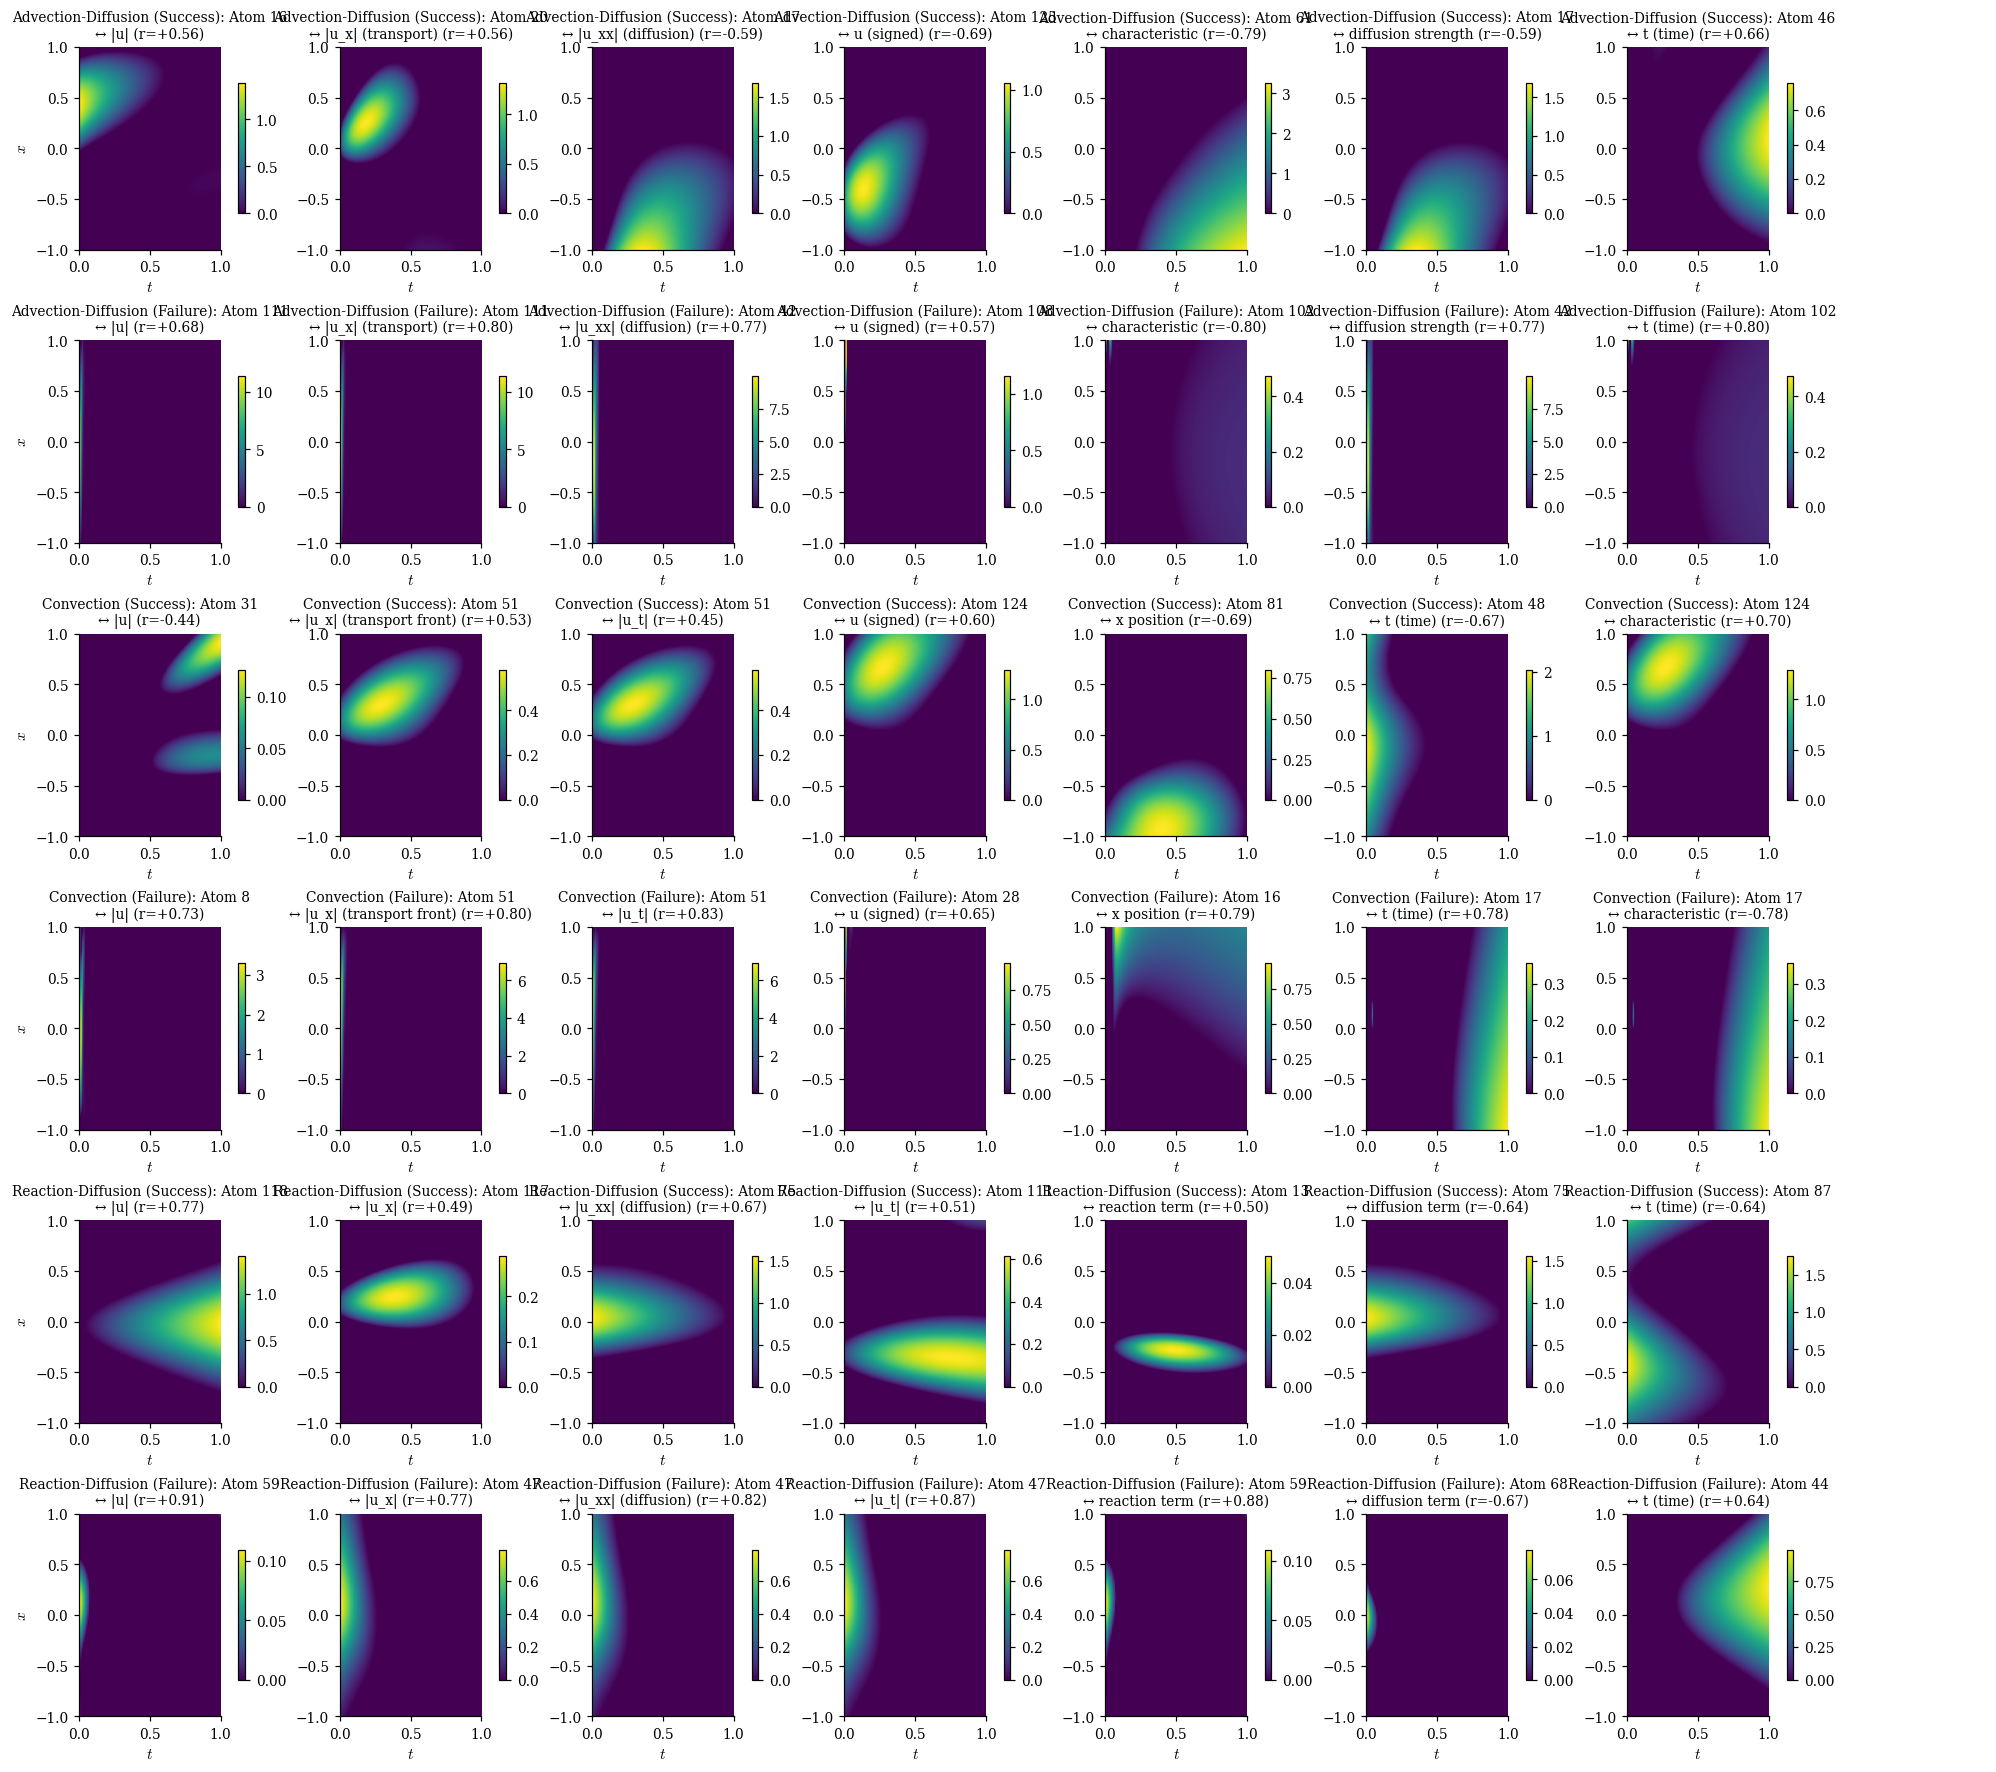

In [57]:
def fig3(d_list):

    fig, axes = plt.subplots(len(d_list),8,figsize=(18,16),constrained_layout=True)

    for row, (Z, A, names, concept_subset, tag) in enumerate(d_list):

        for j_idx, cname in enumerate(concept_subset):
            j = names.index(cname)
            k_top = int(np.argmax(np.abs(A[:, j])))
            r = A[k_top, j]
            zk = Z[..., k_top]
            ax = axes[row, j_idx]
            vmax = zk.max()
            im = ax.imshow(zk,extent=extent,origin="lower",aspect="auto",cmap="viridis",vmin=0,vmax=vmax if vmax > 0 else 1,)

            ax.set_title(
                f"{tag}: Atom {k_top}\n"
                f"↔ {cname} (r={r:+.2f})",
                fontsize=9,
            )

            ax.set_xlabel("$t$")

            if j_idx == 0:
                ax.set_ylabel("$x$")

            plt.colorbar(im, ax=ax, fraction=0.046)

        # Hide unused columns
        for k in range(len(concept_subset), 8):
            axes[row, k].axis("off")

    plt.savefig("figures/fig3_atoms.png",bbox_inches="tight")
    plt.show()

adv_concepts_show = [
    "|u|",
    "|u_x| (transport)",
    "|u_xx| (diffusion)",
    "u (signed)",
    "characteristic",
    "diffusion strength",
    "t (time)",
]

conv_concepts_show = [
    "|u|",
    "|u_x| (transport front)",
    "|u_t|",
    "u (signed)",
    "x position",
    "t (time)",
    "characteristic",
]

reaction_concepts_show = [
    "|u|",
    "|u_x|",
    "|u_xx| (diffusion)",
    "|u_t|",
    "reaction term",
    "diffusion term",
    "t (time)",
]

A_conv_f, _ = alignment(Z_conv_f, C_conv_f)

fig3([

    (
        Z_adv_s,
        A_adv_s,
        names_adv,
        adv_concepts_show,
        "Advection-Diffusion (Success)",
    ),

    (
        Z_adv_f,
        A_adv_f,
        names_adv,
        adv_concepts_show,
        "Advection-Diffusion (Failure)",
    ),

    (
        Z_conv_s,
        A_conv_s,
        names_conv,
        conv_concepts_show,
        "Convection (Success)",
    ),

    (
        Z_conv_f,
        A_conv_f,
        names_conv,
        conv_concepts_show,
        "Convection (Failure)",
    ),

    (
        Z_reac_s,
        A_reac_s,
        names_reac,
        reaction_concepts_show,
        "Reaction-Diffusion (Success)",
    ),

    (
        Z_reac_f,
        A_reac_f,
        names_reac,
        reaction_concepts_show,
        "Reaction-Diffusion (Failure)",
    ),

])

# 9. Ablation — closed-loop causal check - Figure 4



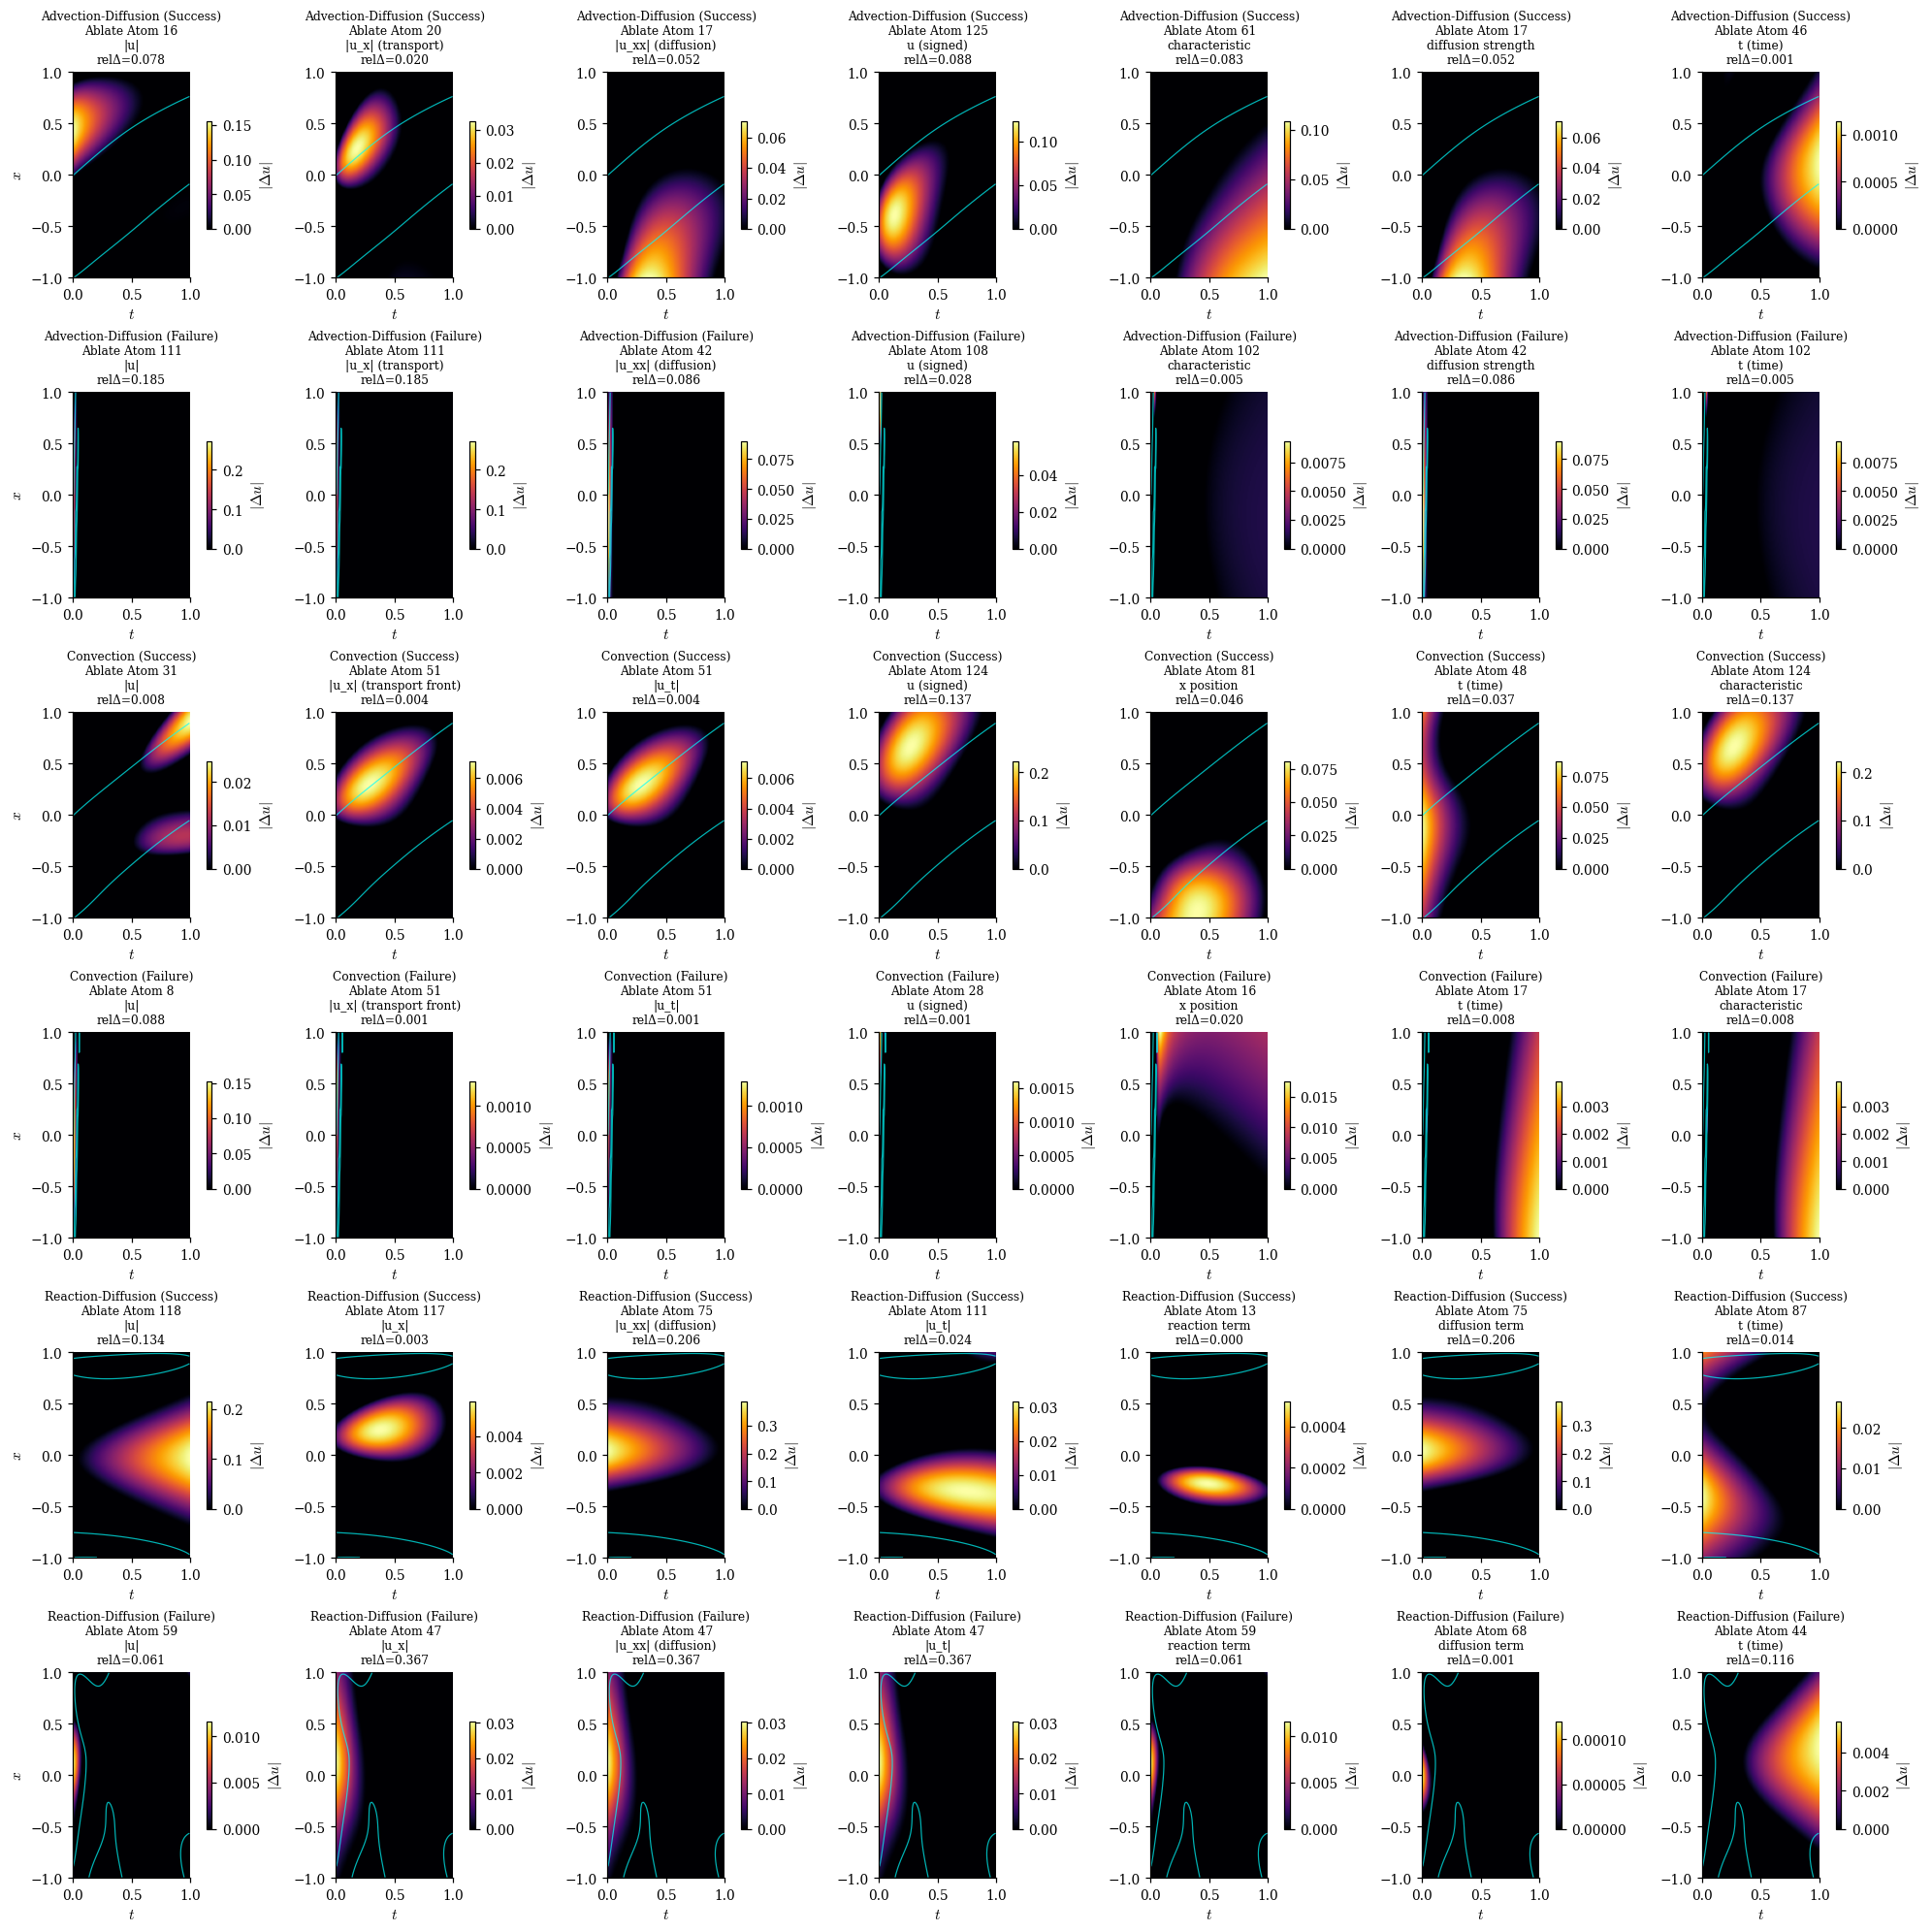

In [58]:
def intervene_ablate(pinn, sae, H, mu, sd, atom_idx):

    H_flat = H.reshape(-1, HIDDEN)

    H_n = (H_flat - mu) / sd

    Ht = torch.from_numpy(H_n).float().to(DEVICE)

    with torch.no_grad():

        z = sae.encode(Ht)

        h_recon_n = (
            sae.decode(z)
            .cpu()
            .numpy()
        )

        z_mod = z.clone()
        z_mod[:, atom_idx] = 0.0

        h_mod_n = (
            sae.decode(z_mod)
            .cpu()
            .numpy()
        )

    h_recon = h_recon_n * sd + mu
    h_mod   = h_mod_n * sd + mu

    W = pinn.net[-1].weight.detach().cpu().numpy()
    b = pinn.net[-1].bias.detach().cpu().numpy()

    u_recon = (h_recon @ W.T + b).reshape(nx, nt)
    u_mod   = (h_mod   @ W.T + b).reshape(nx, nt)

    return u_recon, u_mod, u_recon - u_mod


def fig4(items):

    max_cols = max(len(item[8]) for item in items)

    fig, axes = plt.subplots(
        len(items),
        max_cols,
        figsize=(18,18),
        constrained_layout=True,
    )

    for row, (
        pinn,
        sae,
        H,
        mu,
        sd,
        A,
        names,
        U,
        concepts_to_show,
        tag,
    ) in enumerate(items):

        for j_idx, cname in enumerate(concepts_to_show):

            j = names.index(cname)

            k_top = int(np.argmax(np.abs(A[:, j])))

            u_recon, u_mod, delta = intervene_ablate(
                pinn,
                sae,
                H,
                mu,
                sd,
                k_top,
            )

            ax = axes[row, j_idx]

            adelta = np.abs(delta)

            vmax = adelta.max()

            im = ax.imshow(
                adelta,
                extent=extent,
                origin="lower",
                aspect="auto",
                cmap="inferno",
                vmin=0,
                vmax=vmax if vmax > 0 else 1,
            )

            ax.contour(
                U,
                levels=[0.0],
                extent=extent,
                origin="lower",
                colors="cyan",
                linewidths=0.8,
                alpha=0.7,
            )

            rel = (
                np.linalg.norm(delta)
                /
                (np.linalg.norm(u_recon) + 1e-12)
            )

            ax.set_title(
                f"{tag}\n"
                f"Ablate Atom {k_top}\n"
                f"{cname}\n"
                f"relΔ={rel:.3f}",
                fontsize=8,
            )

            ax.set_xlabel("$t$")

            if j_idx == 0:
                ax.set_ylabel("$x$")

            plt.colorbar(
                im,
                ax=ax,
                fraction=0.046,
                label=r"$|\Delta u|$",
            )

        for k in range(len(concepts_to_show), max_cols):
            axes[row, k].axis("off")

    plt.savefig(
        "figures/fig4_intervention.png",
        bbox_inches="tight",
    )

    plt.show()


fig4([

    (
        ad_models["success"],
        sae_adv_s,
        H_adv_s,
        mu_adv_s,
        sd_adv_s,
        A_adv_s,
        names_adv,
        U_adv_s,
        adv_concepts_show,
        "Advection-Diffusion (Success)",
    ),

    (
        ad_models["failure"],
        sae_adv_f,
        H_adv_f,
        mu_adv_f,
        sd_adv_f,
        A_adv_f,
        names_adv,
        U_adv_f,
        adv_concepts_show,
        "Advection-Diffusion (Failure)",
    ),

    (
        conv_models["success"],
        sae_conv_s,
        H_conv_s,
        mu_conv_s,
        sd_conv_s,
        A_conv_s,
        names_conv,
        U_conv_s,
        conv_concepts_show,
        "Convection (Success)",
    ),

    (
        conv_models["failure"],
        sae_conv_f,
        H_conv_f,
        mu_conv_f,
        sd_conv_f,
        A_conv_f,
        names_conv,
        U_conv_f,
        conv_concepts_show,
        "Convection (Failure)",
    ),

    (
        reac_diff_models["success"],
        sae_reac_s,
        H_reac_s,
        mu_reac_s,
        sd_reac_s,
        A_reac_s,
        names_reac,
        U_reac_s,
        reaction_concepts_show,
        "Reaction-Diffusion (Success)",
    ),

    (
        reac_diff_models["failure"],
        sae_reac_f,
        H_reac_f,
        mu_reac_f,
        sd_reac_f,
        A_reac_f,
        names_reac,
        U_reac_f,
        reaction_concepts_show,
        "Reaction-Diffusion (Failure)",
    ),

])

# 10. Figure 5 — Training dynamics and SAE-vs-PCA bar chart

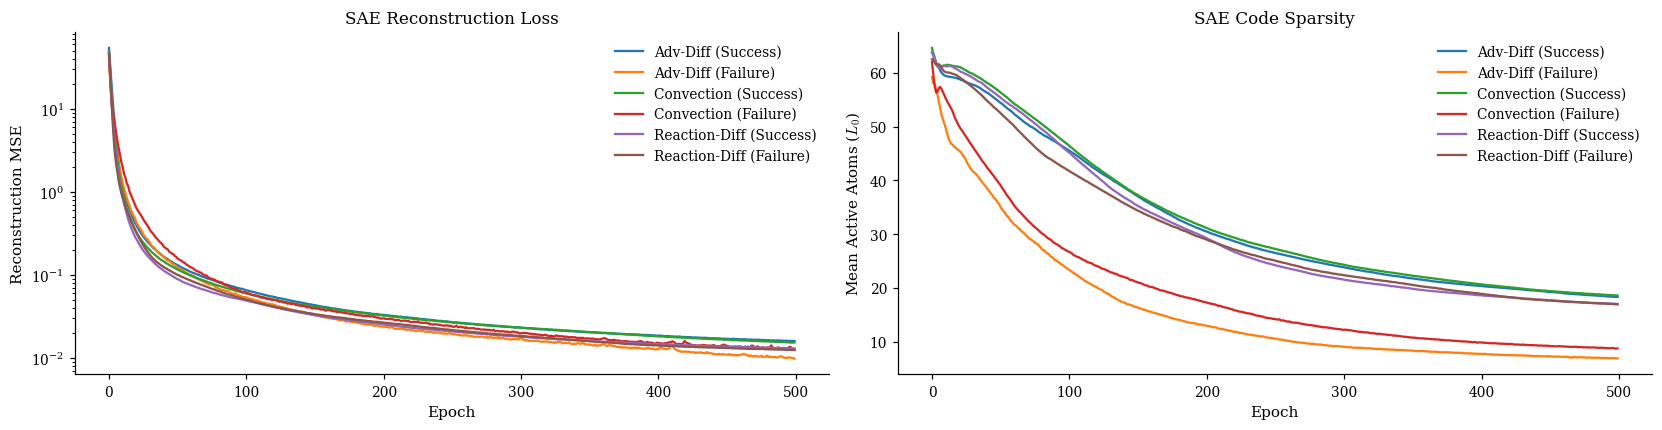

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(15.0, 3.8), constrained_layout=True)


# SAE Reconstruction Loss
ax = axes[0]

ax.plot(sae_hist_adv_s[:,1], label="Adv-Diff (Success)")
ax.plot(sae_hist_adv_f[:,1], label="Adv-Diff (Failure)")

ax.plot(sae_hist_conv_s[:,1], label="Convection (Success)")
ax.plot(sae_hist_conv_f[:,1], label="Convection (Failure)")

ax.plot(sae_hist_reac_s[:,1], label="Reaction-Diff (Success)")
ax.plot(sae_hist_reac_f[:,1], label="Reaction-Diff (Failure)")

ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Reconstruction MSE")
ax.set_title("SAE Reconstruction Loss")
ax.legend(frameon=False)

# Code Sparsity (Mean L0)
ax = axes[1]

ax.plot(sae_hist_adv_s[:,3], label="Adv-Diff (Success)")
ax.plot(sae_hist_adv_f[:,3], label="Adv-Diff (Failure)")

ax.plot(sae_hist_conv_s[:,3], label="Convection (Success)")
ax.plot(sae_hist_conv_f[:,3], label="Convection (Failure)")

ax.plot(sae_hist_reac_s[:,3], label="Reaction-Diff (Success)")
ax.plot(sae_hist_reac_f[:,3], label="Reaction-Diff (Failure)")

ax.set_xlabel("Epoch")
ax.set_ylabel(r"Mean Active Atoms ($L_0$)")
ax.set_title("SAE Code Sparsity")
ax.legend(frameon=False)

plt.savefig(
    "figures/fig5_sparsity_baseline.png",
    bbox_inches="tight"
)

plt.show()

# 11.Failure-mode comparison table

In [62]:
from collections import Counter


def mean_top_alignment(A):
    """Mean absolute alignment of the best atom for each concept."""
    return np.max(np.abs(A), axis=0).mean()


def mean_l0(sae_hist):
    """Final mean active atoms."""
    return sae_hist[-1, 3]


def atom_reuse_index(A):
    """
    Maximum number of concepts explained by the same atom,
    normalized by the total number of concepts.
    """
    top_atoms = np.argmax(np.abs(A), axis=0)
    counts = Counter(top_atoms)
    return max(counts.values()) / len(top_atoms)


def rel_change(success, failure):
    return success - failure


rows = [

    ("Advection-Diffusion",A_adv_s,A_adv_f,sae_hist_adv_s,sae_hist_adv_f,),
    ("Convection",A_conv_s,A_conv_f,sae_hist_conv_s,sae_hist_conv_f,),
    ("Reaction-Diffusion",A_reac_s,A_reac_f,sae_hist_reac_s,sae_hist_reac_f,),
]


print("=" * 120)
print(
    f"{'PDE':22s}"
    f"{'Metric':22s}"
    f"{'Success':>12s}"
    f"{'Failure':>12s}"
    f"{'Δ(S-F)':>12s}"
)
print("=" * 120)

for name, A_s, A_f, hist_s, hist_f in rows:

    # ---------------- Mean Top Alignment ----------------

    s = mean_top_alignment(A_s)
    f = mean_top_alignment(A_f)

    print(
        f"{name:22s}"
        f"{'Mean top alignment':22s}"
        f"{s:12.3f}"
        f"{f:12.3f}"
        f"{rel_change(s, f):12.3f}"
    )

    # ---------------- Atom Reuse Index ----------------

    s = atom_reuse_index(A_s)
    f = atom_reuse_index(A_f)

    print(
        f"{'':22s}"
        f"{'Atom Reuse Index':22s}"
        f"{s:12.3f}"
        f"{f:12.3f}"
        f"{rel_change(s, f):12.3f}"
    )

    # ---------------- Mean L0 ----------------

    s = mean_l0(hist_s)
    f = mean_l0(hist_f)

    print(
        f"{'':22s}"
        f"{'Mean L0':22s}"
        f"{s:12.2f}"
        f"{f:12.2f}"
        f"{rel_change(s, f):12.2f}"
    )

    print("-" * 120)

PDE                   Metric                     Success     Failure      Δ(S-F)
Advection-Diffusion   Mean top alignment           0.630       0.750      -0.120
                      Atom Reuse Index             0.222       0.333      -0.111
                      Mean L0                      18.32        6.91       11.41
------------------------------------------------------------------------------------------------------------------------
Convection            Mean top alignment           0.585       0.766      -0.182
                      Atom Reuse Index             0.286       0.286       0.000
                      Mean L0                      18.59        8.75        9.84
------------------------------------------------------------------------------------------------------------------------
Reaction-Diffusion    Mean top alignment           0.623       0.806      -0.184
                      Atom Reuse Index             0.250       0.375      -0.125
                      Mean L0

# 12. Concept Coverage Analysis

In [68]:
def missing_concepts(A, names, threshold=0.5):
    best_alignment = np.max(np.abs(A), axis=0)

    missing = [
        names[j]
        for j in range(len(names))
        if best_alignment[j] < threshold
    ]

    return best_alignment, missing

In [69]:
def print_missing_concepts(A, names, tag, threshold=0.5):

    best, missing = missing_concepts(A, names, threshold)

    print("=" * 80)
    print(tag)
    print("=" * 80)
    print(f"Threshold = {threshold:.2f}\n")

    print(f"{'Concept':35s} {'Best |r|':>10s} {'Status':>10s}")
    print("-" * 60)

    for name, r in zip(names, best):

        status = "✓ Present" if r >= threshold else "✗ Missing"

        print(
            f"{name:35s}"
            f"{r:10.3f}"
            f"{status:>12s}"
        )

    print("\nSummary")
    print("-" * 30)
    print(f"Present : {len(names)-len(missing)}")
    print(f"Missing : {len(missing)}")

    if missing:
        print("\nMissing concepts:")
        for c in missing:
            print(" -", c)

    return missing

In [73]:
thr = 0.50


missing_adv_f = print_missing_concepts(
    A_adv_f,
    names_adv,
    "Advection-Diffusion (Failure)",
    thr,
)


missing_conv_f = print_missing_concepts(
    A_conv_f,
    names_conv,
    "Convection (Failure)",
    thr,
)


missing_reac_f = print_missing_concepts(
    A_reac_f,
    names_reac,
    "Reaction-Diffusion (Failure)",
    thr,
)

Advection-Diffusion (Failure)
Threshold = 0.50

Concept                               Best |r|     Status
------------------------------------------------------------
|u|                                     0.676   ✓ Present
|u_x| (transport)                       0.804   ✓ Present
|u_xx| (diffusion)                      0.769   ✓ Present
|u_t|                                   0.800   ✓ Present
u (signed)                              0.569   ✓ Present
characteristic                          0.803   ✓ Present
diffusion strength                      0.769   ✓ Present
x position                              0.755   ✓ Present
t (time)                                0.802   ✓ Present

Summary
------------------------------
Present : 9
Missing : 0
Convection (Failure)
Threshold = 0.50

Concept                               Best |r|     Status
------------------------------------------------------------
|u|                                     0.734   ✓ Present
|u_x| (transport front)        

# 13. Monosemanticity Metrics

## Main

In [75]:
def monosemanticity_scores(A):
    """
    Compute monosemanticity score for each atom/component.

    m_k = max_j |A[k,j]|

    Returns
    -------
    mk : ndarray of shape (num_atoms,)
        Maximum absolute concept correlation for every atom.
    """
    return np.max(np.abs(A), axis=1)


# ---------- SAE ----------

mk_adv_s  = monosemanticity_scores(A_adv_s)
mk_adv_f  = monosemanticity_scores(A_adv_f)

mk_conv_s = monosemanticity_scores(A_conv_s)
mk_conv_f = monosemanticity_scores(A_conv_f)

mk_reac_s = monosemanticity_scores(A_reac_s)
mk_reac_f = monosemanticity_scores(A_reac_f)


print("Monosemanticity scores computed.\n")

print(f"Advection-Diffusion (Success) : {mk_adv_s.shape}")
print(f"Advection-Diffusion (Failure) : {mk_adv_f.shape}")

print(f"Convection (Success)          : {mk_conv_s.shape}")
print(f"Convection (Failure)          : {mk_conv_f.shape}")

print(f"Reaction-Diffusion (Success)  : {mk_reac_s.shape}")
print(f"Reaction-Diffusion (Failure)  : {mk_reac_f.shape}")

Monosemanticity scores computed.

Advection-Diffusion (Success) : (128,)
Advection-Diffusion (Failure) : (128,)
Convection (Success)          : (128,)
Convection (Failure)          : (128,)
Reaction-Diffusion (Success)  : (128,)
Reaction-Diffusion (Failure)  : (128,)


## Monosemantic Atom Fraction

In [76]:
THRESHOLD = 0.6

def monosemantic_fraction(mk, threshold=THRESHOLD):
    """
    Fraction of atoms/components with monosemanticity
    score greater than the specified threshold.
    """
    return np.mean(mk > threshold)


# ---------- SAE ----------

frac_adv_s  = monosemantic_fraction(mk_adv_s)
frac_adv_f  = monosemantic_fraction(mk_adv_f)

frac_conv_s = monosemantic_fraction(mk_conv_s)
frac_conv_f = monosemantic_fraction(mk_conv_f)

frac_reac_s = monosemantic_fraction(mk_reac_s)
frac_reac_f = monosemantic_fraction(mk_reac_f)


print(f"{'Advection-Diff (Success)':30s} {frac_adv_s:10.3f}")
print(f"{'Advection-Diff (Failure)':30s} {frac_adv_f:10.3f}")

print(f"{'Convection (Success)':30s}     {frac_conv_s:10.3f}")
print(f"{'Convection (Failure)':30s}     {frac_conv_f:10.3f}")

print(f"{'Reaction-Diff (Success)':30s}  {frac_reac_s:10.3f}")
print(f"{'Reaction-Diff (Failure)':30s}  {frac_reac_f:10.3f}")

Advection-Diff (Success)            0.148
Advection-Diff (Failure)            0.156
Convection (Success)                    0.117
Convection (Failure)                    0.172
Reaction-Diff (Success)              0.062
Reaction-Diff (Failure)              0.125


# 14. Feature density

In [77]:
EPSILON = 1e-6

def feature_density(Z, eps=EPSILON):
    Z_flat = Z.reshape(-1, Z.shape[-1])
    return np.mean(Z_flat > eps, axis=0)


# ---------- SAE ----------

density_adv_s  = feature_density(Z_adv_s)
density_adv_f  = feature_density(Z_adv_f)

density_conv_s = feature_density(Z_conv_s)
density_conv_f = feature_density(Z_conv_f)

density_reac_s = feature_density(Z_reac_s)
density_reac_f = feature_density(Z_reac_f)


print("Feature density computed.\n")

print(f"Advection-Diffusion (Success) : {density_adv_s.shape}")
print(f"Advection-Diffusion (Failure) : {density_adv_f.shape}")

print(f"Convection (Success)          : {density_conv_s.shape}")
print(f"Convection (Failure)          : {density_conv_f.shape}")

print(f"Reaction-Diffusion (Success)  : {density_reac_s.shape}")
print(f"Reaction-Diffusion (Failure)  : {density_reac_f.shape}")

Feature density computed.

Advection-Diffusion (Success) : (128,)
Advection-Diffusion (Failure) : (128,)
Convection (Success)          : (128,)
Convection (Failure)          : (128,)
Reaction-Diffusion (Success)  : (128,)
Reaction-Diffusion (Failure)  : (128,)



Advection-Diffusion (Success)
-----------------------------
mean_mk             : 0.3724
median_mk           : 0.3755
std_mk              : 0.1926
fraction_gt_0.6     : 0.1484
mean_density        : 0.1430
median_density      : 0.1154
std_density         : 0.1126

Advection-Diffusion (Failure)
-----------------------------
mean_mk             : 0.3798
median_mk           : 0.3986
std_mk              : 0.2186
fraction_gt_0.6     : 0.1562
mean_density        : 0.0541
median_density      : 0.0137
std_density         : 0.1146

Convection (Success)
--------------------
mean_mk             : 0.3680
median_mk           : 0.3909
std_mk              : 0.1972
fraction_gt_0.6     : 0.1172
mean_density        : 0.1452
median_density      : 0.1221
std_density         : 0.1123

Convection (Failure)
--------------------
mean_mk             : 0.4022
median_mk           : 0.4092
std_mk              : 0.1967
fraction_gt_0.6     : 0.1719
mean_density        : 0.0682
median_density      : 0.0188
std_densi

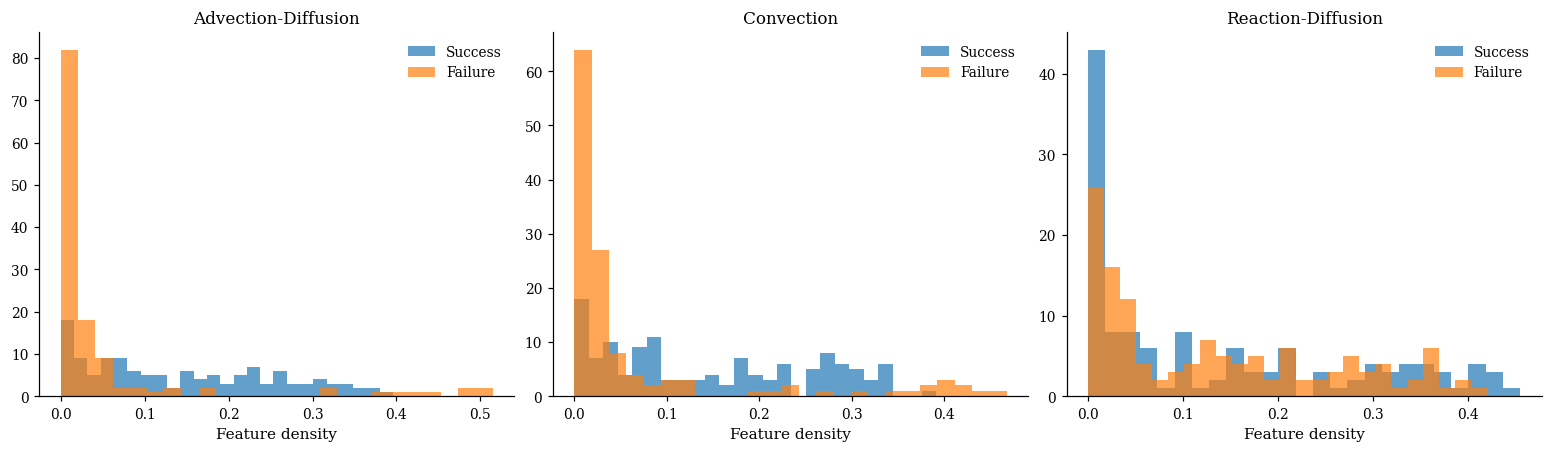

In [78]:
def summary_statistics(mk, density, fraction):
    """
    Compute summary statistics for one experiment.
    """
    return {

        "mean_mk": np.mean(mk),
        "median_mk": np.median(mk),
        "std_mk": np.std(mk),

        "fraction_gt_0.6": fraction,

        "mean_density": np.mean(density),
        "median_density": np.median(density),
        "std_density": np.std(density),

    }


summary = {

    "Advection-Diffusion (Success)":
        summary_statistics(
            mk_adv_s,
            density_adv_s,
            frac_adv_s,
        ),

    "Advection-Diffusion (Failure)":
        summary_statistics(
            mk_adv_f,
            density_adv_f,
            frac_adv_f,
        ),

    "Convection (Success)":
        summary_statistics(
            mk_conv_s,
            density_conv_s,
            frac_conv_s,
        ),

    "Convection (Failure)":
        summary_statistics(
            mk_conv_f,
            density_conv_f,
            frac_conv_f,
        ),

    "Reaction-Diffusion (Success)":
        summary_statistics(
            mk_reac_s,
            density_reac_s,
            frac_reac_s,
        ),

    "Reaction-Diffusion (Failure)":
        summary_statistics(
            mk_reac_f,
            density_reac_f,
            frac_reac_f,
        ),
}


# ---------- Print Summary ----------

for exp in summary:

    print(f"\n{exp}")
    print("-" * len(exp))

    for k, v in summary[exp].items():
        print(f"{k:20s}: {v:.4f}")


fig, axes = plt.subplots(1,3, figsize=(14,4), constrained_layout=True)

# Advection-Diffusion
axes[0].hist(density_adv_s, bins=25, alpha=0.7, label="Success")
axes[0].hist(density_adv_f, bins=25, alpha=0.7, label="Failure")
axes[0].set_title("Advection-Diffusion")
axes[0].set_xlabel("Feature density")
axes[0].legend(frameon=False)

# Convection
axes[1].hist(density_conv_s, bins=25, alpha=0.7, label="Success")
axes[1].hist(density_conv_f, bins=25, alpha=0.7, label="Failure")
axes[1].set_title("Convection")
axes[1].set_xlabel("Feature density")
axes[1].legend(frameon=False)

# Reaction-Diffusion
axes[2].hist(density_reac_s, bins=25, alpha=0.7, label="Success")
axes[2].hist(density_reac_f, bins=25, alpha=0.7, label="Failure")
axes[2].set_title("Reaction-Diffusion")
axes[2].set_xlabel("Feature density")
axes[2].legend(frameon=False)

plt.savefig(
    "figures/feature_density_histograms.png",
    bbox_inches="tight",
)

plt.show()